# TorchSig Geolocation Demo

TorchSig Workshop: GRCon 2026

## Install Dependencies

In [1]:
!pip install -q torchsig


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!curl -sL https://github.com/TorchDSP/torchsig/releases/download/v2.2.0/grcon26-assets.zip -o assets.zip
!unzip assets.zip
!mv grcon26-assets/geo/* .
!rm -rf ctf grcon26-assets
!rm assets.zip

Archive:  assets.zip
   creating: grcon26-assets
   creating: grcon26-assets/ctf
   creating: grcon26-assets/ctf/captures
  inflating: grcon26-assets/ctf/captures/capture_05.sigmf-meta  
  inflating: grcon26-assets/ctf/captures/capture_01.sigmf-meta  
  inflating: grcon26-assets/ctf/captures/capture_04.sigmf-data  
  inflating: grcon26-assets/ctf/captures/capture_02.sigmf-data  
  inflating: grcon26-assets/ctf/captures/capture_05.sigmf-data  
  inflating: grcon26-assets/ctf/captures/capture_01.sigmf-data  
  inflating: grcon26-assets/ctf/captures/capture_03.sigmf-meta  
  inflating: grcon26-assets/ctf/captures/capture_03.sigmf-data  
  inflating: grcon26-assets/ctf/captures/metadata.csv  
  inflating: grcon26-assets/ctf/captures/capture_04.sigmf-meta  
  inflating: grcon26-assets/ctf/captures/capture_02.sigmf-meta  
  inflating: grcon26-assets/ctf/requirements.txt  
  inflating: grcon26-assets/ctf/generate_captures.py  
  inflating: grcon26-assets/ctf/README.md  
  inflating: grcon26-a

In [3]:
# Import TorchSig components
from torchsig.datasets.datasets import TorchSigIterableDataset
from torchsig.geo.types import GeoPoint
from torchsig.geo.datasets import TorchSigGeoDataset, Transmitter, Receiver
from torchsig.geo.transforms import PathLoss, PathDelay
from torchsig.utils.defaults import TorchSigDefaults
from torchsig.transforms.transforms import Spectrogram

# Import example utility functions for visualization and geolocation
import matplotlib.pyplot as plt

from geo_example_utils import (
    plot_geo_network_at_frame,
)

/Users/ereoh/Downloads/GRCon_2026/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## `TorchSigGeoDataset` Config

In [4]:
# Constants
NUM_SAMPLES = 262144
SAMPLE_RATE = 10_000_000 # 10 MHz
FFT_N = 512

# Modify default metadata
defaults = TorchSigDefaults()
gds_metadata = defaults.default_dataset_metadata.copy()

# Signal properties
gds_metadata["num_iq_samples_dataset"] = NUM_SAMPLES
gds_metadata["sample_rate"] = SAMPLE_RATE
gds_metadata["signal_center_freq_min"] = 250_000
gds_metadata["signal_center_freq_max"] = 750_000

# Spectrogram properties
gds_metadata["fft_size"] = FFT_N
gds_metadata["fft_stride"] = FFT_N
gds_metadata["frequency_min"] = -SAMPLE_RATE # for global antialiasing filter
gds_metadata["frequency_max"] = SAMPLE_RATE

## Define Geometry

In [5]:
CENTER  = (37.7749, -122.4194, 100) # San Francisco

tx_pos  = GeoPoint(CENTER[0], CENTER[1], CENTER[2]) # centered

rx1_pos = GeoPoint(CENTER[0],       CENTER[1] - 0.1, CENTER[2] + 1000) # West
rx2_pos = GeoPoint(CENTER[0],       CENTER[1] + 0.1, CENTER[2] + 1000) # East
rx3_pos = GeoPoint(CENTER[0] - 0.1, CENTER[1],       CENTER[2] + 1000) # South

## `Transmitter` and `Receiver` Construction

In [6]:
# Create RX
rx1 = Receiver(rx1_pos, SAMPLE_RATE, identifier="rx1")
rx2 = Receiver(rx2_pos, SAMPLE_RATE, identifier="rx2")
rx3 = Receiver(rx3_pos, SAMPLE_RATE, identifier="rx3")

# create TX
txds_metadata = gds_metadata.copy()
txds          = TorchSigIterableDataset(
                    metadata=txds_metadata,
                    signal_generators=["qpsk"],
                    seed=42)
tx = Transmitter(txds, tx_pos, identifier="tx")

## Plot the geometry

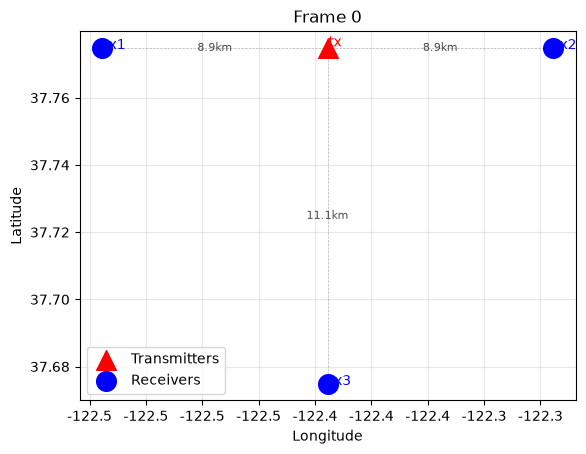

In [7]:
from matplotlib.ticker import FormatStrFormatter

fig, ax = plt.subplots(1,1)
ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))

plot_geo_network_at_frame([tx],
                          [rx1, rx2, rx3],
                          0, connections=True, ax=ax)

plt.show()

## Putting it all together

In [8]:
gds = TorchSigGeoDataset(
    transmitters=[tx],
    receivers=[rx1,rx2,rx3],
    channel_transforms=[PathLoss(model="custom", loss_db=2), PathDelay()]
)

## Generating Samples

In [9]:
s1 = next(gds)
s2 = next(gds)
s3 = next(gds)

## Plot received signals

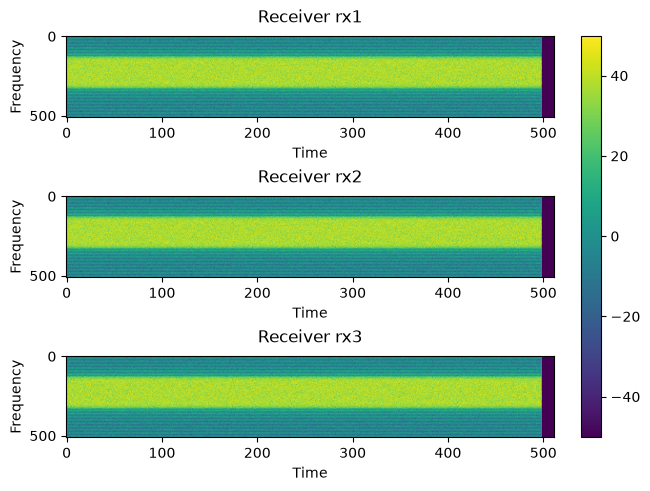

In [10]:
fig, ax = plt.subplots(3,constrained_layout=True)

for i,s in enumerate([s1,s2,s3]):

    # plot spectrogram
    rx_spectrogram = Spectrogram(fft_size=FFT_N)(s.copy())
    im    = ax[i].imshow(rx_spectrogram.data, aspect='auto', cmap='viridis')

    # pretty the labels
    ax[i].set_title(f"Receiver {s['rx_id']}", pad=10)
    ax[i].set_xlabel('Time')
    ax[i].set_ylabel('Frequency')

fig.colorbar(im, ax=ax)
plt.show()